PNN σε διο διαφορετικα task με 2 διαφορετικά dataset MNIST και MNIST fashion

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

BATCH_SIZE = 128
EPOCHS_PER_TASK = 5

# Κοινός μετασχηματισμός (και τα δύο είναι 1x28x28 grayscale)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- Φόρτωση των ΔΥΟ διαφορετικών Datasets ---
print("Λήψη του MNIST (Task 1)...")
train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print("Λήψη του Fashion-MNIST (Task 2)...")
train_fashion = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_fashion = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

Το μοντέλο θα τρέξει σε: cuda
Λήψη του MNIST (Task 1)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


Λήψη του Fashion-MNIST (Task 2)...


100%|██████████| 26.4M/26.4M [00:06<00:00, 4.15MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.5MB/s]


In [2]:
# Δημιουργία των Loaders (Κάθε Task έχει το δικό του ολόκληρο dataset)
train_loaders = [
    DataLoader(train_mnist, batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(train_fashion, batch_size=BATCH_SIZE, shuffle=True)
]
test_loaders = [
    DataLoader(test_mnist, batch_size=BATCH_SIZE, shuffle=False),
    DataLoader(test_fashion, batch_size=BATCH_SIZE, shuffle=False)
]

dataset_names = ['MNIST', 'Fashion-MNIST']
print("Οι Loaders για τα 2 διαφορετικά Domains δημιουργήθηκαν!")

Οι Loaders για τα 2 διαφορετικά Domains δημιουργήθηκαν!


In [3]:
# --- 1. ΒΑΣΙΚΟ CNN ΓΙΑ NAIVE ΚΑΙ BUFFER ---
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Μετά από δύο poolings (28x28 -> 14x14 -> 7x7)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        return self.fc2(F.relu(self.fc1(x)))

# --- 2. PROGRESSIVE NEURAL NETWORKS (PNN) ---
class PNN(nn.Module):
    def __init__(self, layer_sizes=[28 * 28, 512, 256, 10]):
        super(PNN, self).__init__()
        self.layer_sizes = layer_sizes
        self.n_tasks = 0
        self.columns = nn.ModuleList()
        self.lateral = nn.ModuleDict()

    def add_task(self):
        self.n_tasks += 1
        task_idx = self.n_tasks - 1
        col = nn.ModuleList([nn.Linear(self.layer_sizes[i], self.layer_sizes[i+1]) for i in range(len(self.layer_sizes) - 1)])
        self.columns.append(col)

        if task_idx > 0:
            for l in range(1, len(self.layer_sizes) - 1):
                for prev_t in range(task_idx):
                    self.lateral[f"t{task_idx}_l{l}_prev{prev_t}"] = nn.Linear(self.layer_sizes[l], self.layer_sizes[l+1])

    def freeze_columns(self, up_to_task):
        for t in range(up_to_task):
            for param in self.columns[t].parameters(): param.requires_grad = False
        for k, v in self.lateral.items():
            if int(k.split('_')[0][1:]) < up_to_task:
                for param in v.parameters(): param.requires_grad = False

    def forward(self, x, task_id):
        x = x.view(-1, 28 * 28)
        activations = [[x] for _ in range(task_id + 1)]
        for l in range(len(self.layer_sizes) - 1):
            for t in range(task_id + 1):
                out = self.columns[t][l](activations[t][l])
                if l > 0 and t > 0:
                    for prev_t in range(t):
                        out += self.lateral[f"t{t}_l{l}_prev{prev_t}"](activations[prev_t][l])
                if l < len(self.layer_sizes) - 2: out = F.relu(out)
                activations[t].append(out)
        return activations[task_id][-1]

# --- 3. ΣΥΝΑΡΤΗΣΕΙΣ ΑΞΙΟΛΟΓΗΣΗΣ ---
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct, total = 0, 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                _, pred = torch.max(model(data), 1)
                total += target.size(0); correct += (pred == target).sum().item()
            accuracies.append(100 * correct / total)
    return accuracies

def evaluate_model_pnn(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct, total = 0, 0
            for data, target in test_loaders[i]:
                outputs = model(data.to(device), task_id=i)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target.to(device)).sum().item()
            accuracies.append(100 * correct / total)
    return accuracies

def calculate_forgetting(acc_matrix):
    f = []
    # Επειδή έχουμε μόνο 2 tasks, ελέγχουμε μόνο το Task 0
    if len(acc_matrix) > 1:
        max_past = acc_matrix[0][0]
        f.append(max_past - acc_matrix[-1][0])
    return np.mean(f) if f else 0

In [4]:
print("\n=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===")
naive_classifier = CNNClassifier().to(device)
opt_naive = optim.Adam(naive_classifier.parameters(), lr=0.001)
naive_acc_matrix = []

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση NAIVE στο Dataset {dataset_names[task_idx]}...")
    naive_classifier.train()

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt_naive.zero_grad()
            loss = criterion(naive_classifier(data), target)
            loss.backward()
            opt_naive.step()

    accs = evaluate_model(naive_classifier, test_loaders, task_idx)
    naive_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===
---> Εκπαίδευση NAIVE στο Dataset MNIST...
Αποτελέσματα: [98.98]
---> Εκπαίδευση NAIVE στο Dataset Fashion-MNIST...
Αποτελέσματα: [19.93, 90.66]


In [5]:
print("\n=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===")
buffer_classifier = CNNClassifier().to(device)
opt_buffer = optim.Adam(buffer_classifier.parameters(), lr=0.001)
buffer_acc_matrix = []
memory_data, memory_targets = [], []

# Κρατάμε 2000 εικόνες από το MNIST για να θυμάται
SAMPLES_PER_TASK = 4000

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση BUFFER στο Dataset {dataset_names[task_idx]}...")
    buffer_classifier.train()

    task_d, task_t = [], []
    for d, t in train_loader:
        task_d.append(d)
        task_t.append(t)
    memory_data.append(torch.cat(task_d)[:SAMPLES_PER_TASK])
    memory_targets.append(torch.cat(task_t)[:SAMPLES_PER_TASK])

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            if task_idx > 0:
                old_d = torch.cat(memory_data[:task_idx]).to(device)
                old_t = torch.cat(memory_targets[:task_idx]).to(device)
                # Παίρνουμε τυχαίο sample από τη μνήμη ίδιου μεγέθους με το batch
                idx = torch.randperm(len(old_d))[:len(data)]
                data = torch.cat([data, old_d[idx]])
                target = torch.cat([target, old_t[idx]])

            opt_buffer.zero_grad()
            loss = criterion(buffer_classifier(data), target)
            loss.backward()
            opt_buffer.step()

    accs = evaluate_model(buffer_classifier, test_loaders, task_idx)
    buffer_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===
---> Εκπαίδευση BUFFER στο Dataset MNIST...
Αποτελέσματα: [98.95]
---> Εκπαίδευση BUFFER στο Dataset Fashion-MNIST...
Αποτελέσματα: [97.94, 90.7]


In [6]:
print("\n=== ΕΚΤΕΛΕΣΗ 3/3: PROGRESSIVE NEURAL NETWORKS (PNN) ===")

pnn_model = PNN().to(device)
pnn_acc_matrix = []

for task_idx, train_loader in enumerate(train_loaders):
    print(f"\n---> Εκπαίδευση PNN στο Dataset {dataset_names[task_idx]}...")

    pnn_model.add_task()
    pnn_model.to(device)
    pnn_model.freeze_columns(up_to_task=task_idx)

    optimizer_pnn = optim.Adam(filter(lambda p: p.requires_grad, pnn_model.parameters()), lr=0.001)
    pnn_model.train()

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            optimizer_pnn.zero_grad()
            outputs = pnn_model(data.to(device), task_id=task_idx)
            loss = criterion(outputs, target.to(device))
            loss.backward()
            optimizer_pnn.step()

    accs = evaluate_model_pnn(pnn_model, test_loaders, task_idx)
    pnn_acc_matrix.append(accs)
    print(f" -> Ακρίβεια: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 3/3: PROGRESSIVE NEURAL NETWORKS (PNN) ===

---> Εκπαίδευση PNN στο Dataset MNIST...
 -> Ακρίβεια: [97.48]

---> Εκπαίδευση PNN στο Dataset Fashion-MNIST...
 -> Ακρίβεια: [97.48, 86.81]


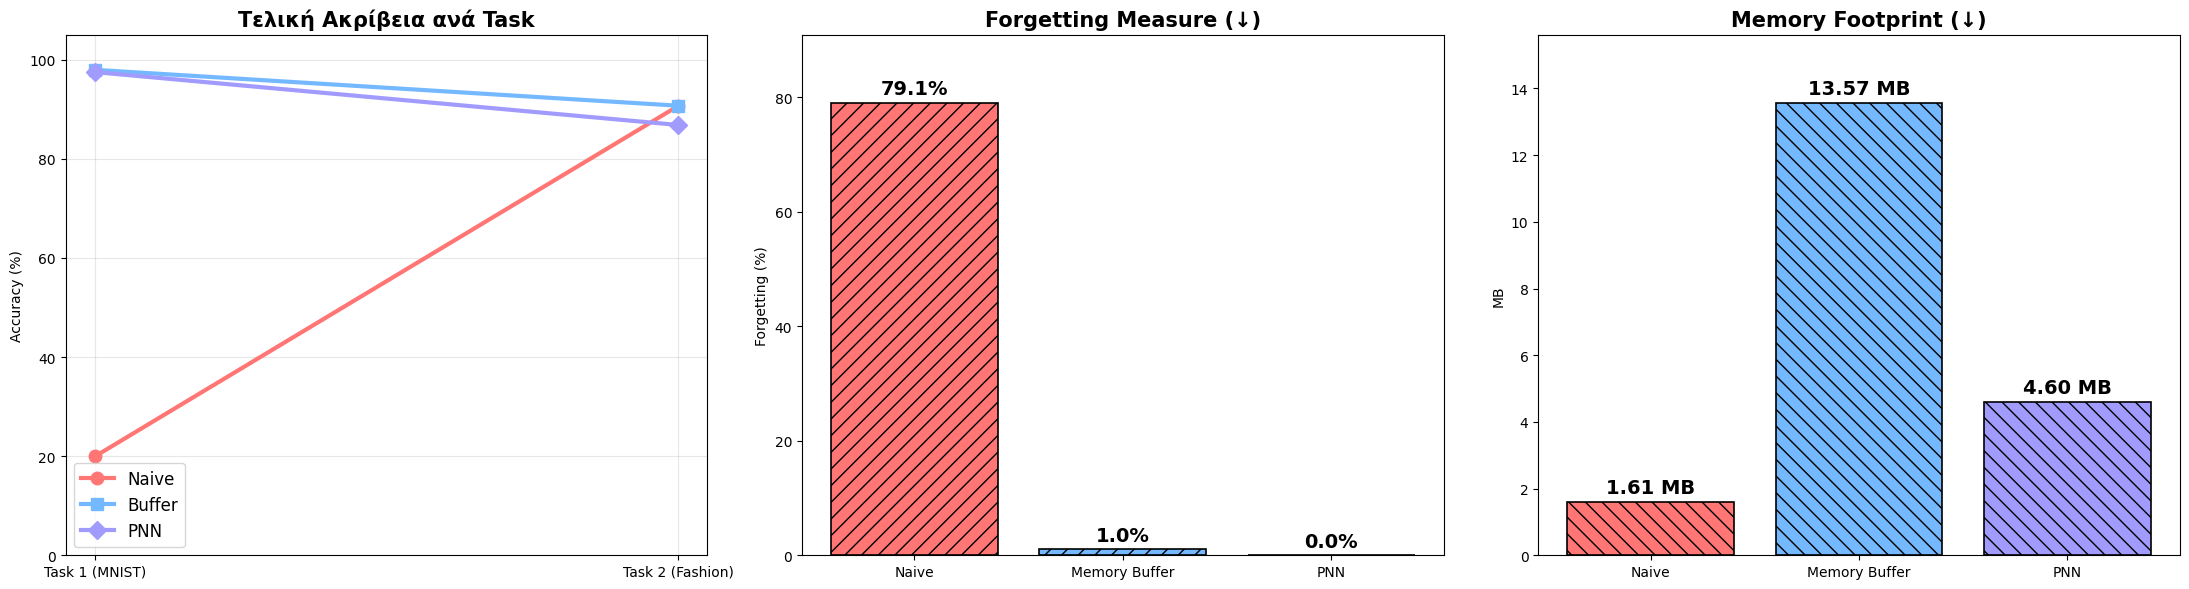

In [7]:
def pad_accuracies(acc_matrix):
    padded = []
    # Τώρα έχουμε 2 Tasks, άρα το padding πάει μέχρι το 2
    for row in acc_matrix:
        padded_row = list(row) + [np.nan] * (2 - len(row))
        padded.append(padded_row)
    return padded

f_naive = pad_accuracies(naive_acc_matrix)[-1]
f_buffer = pad_accuracies(buffer_acc_matrix)[-1]
f_pnn = pad_accuracies(pnn_acc_matrix)[-1]

forg_naive = calculate_forgetting(pad_accuracies(naive_acc_matrix))
forg_buffer = calculate_forgetting(pad_accuracies(buffer_acc_matrix))
# Στο PNN το forgetting είναι ΜΗΔΕΝ από τη σχεδίαση:
forg_pnn = calculate_forgetting(pad_accuracies(pnn_acc_matrix))

# Υπολογισμός Μνήμης
cls_mb = (sum(p.numel() for p in CNNClassifier().parameters()) * 4) / (1024 ** 2)
mem_naive = cls_mb
# Memory Buffer: 2000 εικόνες * 1 κανάλι * 28x28 * 4 bytes
mem_buffer = cls_mb + ((4000 * 1 * 28 * 28 * 4) / (1024 ** 2))

# Το PNN αυξάνει τη μνήμη του δυναμικά.
mem_pnn = (sum(p.numel() for p in pnn_model.parameters()) * 4) / (1024 ** 2)

# --- PLOTS ΑΚΡΙΒΩΣ ΟΠΩΣ ΣΤΗΝ ΕΙΚΟΝΑ ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
methods = ['Naive', 'Memory Buffer', 'PNN']
colors = ['#ff7675', '#74b9ff', '#a29bfe']

# 1. Line Plot
# Έχουμε 2 tasks: [MNIST, Fashion]
x_labels = ['Task 1 (MNIST)', 'Task 2 (Fashion)']
axes[0].plot(x_labels, f_naive, marker='o', lw=3, ms=9, color=colors[0], label='Naive')
axes[0].plot(x_labels, f_buffer, marker='s', lw=3, ms=9, color=colors[1], label='Buffer')
axes[0].plot(x_labels, f_pnn, marker='D', lw=3, ms=9, color=colors[2], label='PNN')
axes[0].set_title('Τελική Ακρίβεια ανά Task', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=12, loc='lower left')

# 2. Bar Plot (Forgetting Measure)
f_vals = [forg_naive, forg_buffer, forg_pnn]
axes[1].bar(methods, f_vals, color=colors, edgecolor='black', linewidth=1.2, hatch='//')
axes[1].set_title('Forgetting Measure (↓)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Forgetting (%)')
axes[1].set_ylim(0, max(f_vals) * 1.15 if max(f_vals) > 0 else 105)
for i, v in enumerate(f_vals):
    axes[1].text(i, v + 1.5, f"{max(0, v):.1f}%", ha='center', fontweight='bold', fontsize=14)

# 3. Bar Plot (Memory Footprint)
m_vals = [mem_naive, mem_buffer, mem_pnn]
axes[2].bar(methods, m_vals, color=colors, edgecolor='black', linewidth=1.2, hatch='\\\\')
axes[2].set_title('Memory Footprint (↓)', fontsize=15, fontweight='bold')
axes[2].set_ylabel('MB')
axes[2].set_ylim(0, max(m_vals) * 1.15)
for i, v in enumerate(m_vals):
    axes[2].text(i, v + (max(m_vals)*0.02), f"{v:.2f} MB", ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()